In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import datetime as dt

df = pd.read_csv('fmcg_sales_3years_1M_rows.csv')
df.head(5)

,date,year,month,day,weekofyear,weekday,is_weekend,is_holiday,temperature,rain_mm,...,discount_pct,promo_flag,gross_sales,net_sales,stock_on_hand,stock_out_flag,lead_time_days,supplier_id,purchase_cost,margin_pct
0,2021-01-01,2021,1,1,53,4,0,1,8.44,1.24,...,0.1,1,167.84,151.06,248,0,11,S008,7.53,0.182
1,2021-01-02,2021,1,2,53,5,1,0,12.61,1.12,...,0.0,0,125.88,125.88,238,0,6,S057,5.19,0.505
2,2021-01-03,2021,1,3,53,6,1,0,12.02,2.69,...,0.3,1,398.62,279.03,238,0,6,S017,5.59,0.168
3,2021-01-04,2021,1,4,1,0,0,0,7.76,4.65,...,0.0,0,83.92,83.92,216,0,7,S012,7.81,0.255
4,2021-01-05,2021,1,5,1,1,0,0,11.16,1.77,...,0.2,1,178.33,142.66,372,0,8,S038,7.62,0.073


In [3]:
def country_sales():
    sales_by_country = df.groupby('country')['net_sales'].sum().reset_index()
    sales_by_country = sales_by_country.set_index('country')
    return sales_by_country

print(country_sales().sort_values(by='net_sales', ascending=False))

                net_sales
country                  
Italy        1.371931e+08
Spain        1.067048e+08
Germany      8.852556e+07
Austria      4.302003e+07
France       4.260161e+07
Poland       4.238526e+07
Netherlands  1.251615e+07


In [8]:
#Ranking SKUs by revenues (cumulative gross sales)
skus = df.groupby(['sku_id', 'sku_name'])['gross_sales'].sum().reset_index()
skus = skus.set_index('sku_id')
sku_revenues = skus.sort_values(by='gross_sales', ascending=False)
print("Total SKUs:", sku_revenues['sku_name'].count())
print(sku_revenues.head(20))

Total SKUs: 102
                  sku_name  gross_sales
sku_id                                 
SKU0018       BrandF Water  17032424.64
SKU0027       BrandC Chips  16992692.55
SKU0099  BrandC Toothpaste  13865061.24
SKU0026       BrandB Chips  13025419.73
SKU0092        BrandB Soap  12496995.90
SKU0100  BrandD Toothpaste  12351150.68
SKU0064      BrandD Cheese  12326994.00
SKU0061      BrandA Cheese  11967260.40
SKU0028       BrandD Chips  11749108.59
SKU0041    BrandE Biscuits  11617656.00
SKU0097  BrandA Toothpaste  11594508.71
SKU0001        BrandA Soda  11184457.44
SKU0038    BrandB Biscuits  10826032.60
SKU0058        BrandD Milk  10664140.20
SKU0005        BrandE Soda  10329030.00
SKU0057        BrandC Milk  10224239.22
SKU0048        BrandF Nuts   9474373.26
SKU0060        BrandF Milk   9466848.00
SKU0045        BrandC Nuts   8631958.72
SKU0002        BrandB Soda   8625588.75


In [42]:
#ABC Classification of SKUs based on revenues
A_threshold = 0.80
B_threshold = 0.95
df['value'] = df['units_sold'] * df['list_price']

def abc_analysis(df):
    sku_class = []

    for country, group in df.groupby('country'):
        # Sort SKUs by value descending
        sku_sales = (
            group.groupby(['sku_id', 'sku_name'])['value']
            .sum()
            .reset_index()
            .sort_values(by='value', ascending=False)
        )

        sku_sales['cumulative_value'] = sku_sales['value'].cumsum()
        total_demand_country = sku_sales['value'].sum()

        A_threshold_country = total_demand_country * A_threshold
        B_threshold_country = total_demand_country * B_threshold
        
        # Classifying SKUs into A, B, C
        sku_sales['class'] = 'C'
        sku_sales.loc[sku_sales['cumulative_value'] <= A_threshold_country, 'class'] = 'A'
        sku_sales.loc[
            (sku_sales['cumulative_value'] > A_threshold_country) &
            (sku_sales['cumulative_value'] <= B_threshold_country),
            'class'
        ] = 'B'
        
        # Add country column
        sku_sales['country'] = country

        #Append SKU data
        sku_class.append(sku_sales)
    
    return pd.concat(sku_class, ignore_index=True)

abc_sku = abc_analysis(df)
abc_sku.to_csv('abc_sku_classification.csv', index=False)

summary = abc_sku.groupby(['country', 'class']).agg(
    num_skus=('sku_id', 'count'),
    total_value=('value', 'sum')
).reset_index()

print(summary.pivot_table(index='country', columns='class',values=['num_skus', 'total_value'],aggfunc='sum'))

            num_skus           total_value                         
class              A   B   C             A            B           C
country                                                            
Austria           38  23  19  3.512531e+07   6603949.61  2289508.88
France            37  23  20  3.451854e+07   6778713.21  2333880.83
Germany           45  27  26  7.257562e+07  13428968.64  4762012.06
Italy             49  28  25  1.119071e+08  21188829.46  7532480.62
Netherlands       21  13  11  1.017837e+07   2033401.19   676727.89
Poland            39  23  18  3.454777e+07   6733623.51  2254090.86
Spain             47  28  25  8.742152e+07  16281405.57  5576815.01


In [6]:
sku_stats = df.groupby(['sku_id', 'sku_name'])['value'].agg(mean='mean', std_dev='std').reset_index()
sku_stats['mean'] = sku_stats['mean'].round(2)
sku_stats['std_dev'] = sku_stats['std_dev'].round(2)
sku_stats['cv'] = sku_stats['std_dev'] / sku_stats['mean']
sku_stats['cv'] = sku_stats['cv'].round(2)
x_threshold = 0.20
y_threshold = 0.50

def assign_volatility(cv):
    if cv <= x_threshold:
        return 'X'
    elif cv <= y_threshold:
        return 'Y'
    else:
        return 'Z'

sku_stats['xyz'] = sku_stats['cv'].apply(assign_volatility)
sku_stats.to_csv('sku_xyz_analysis_value.csv', index=False)

In [7]:
#Find correlation between list_price, units_sold, and promo_flag
correlation_matrix = df[['list_price', 'units_sold', 'promo_flag']].corr()
print(correlation_matrix)

            list_price  units_sold  promo_flag
list_price    1.000000   -0.082791   -0.047780
units_sold   -0.082791    1.000000    0.295772
promo_flag   -0.047780    0.295772    1.000000


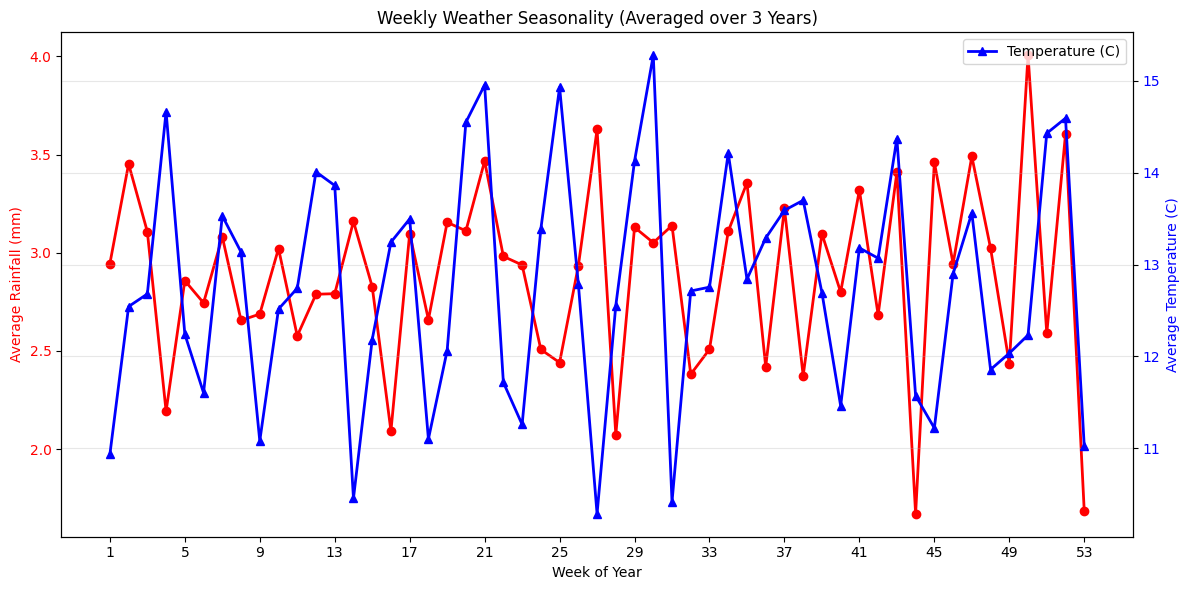

In [8]:
'''Weekly seasonality
Grouping by week and using avg for each week over the 3 years.

'''
weekly_data = df.groupby('weekofyear').agg(
    rain_mm=('rain_mm', 'mean'),
    temperature=('temperature', 'mean')
).reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(weekly_data['weekofyear'], weekly_data['rain_mm'], label='Rainfall (mm)', color='r', marker='o', linewidth=2)
ax.set_xlabel('Week of Year')
ax.set_ylabel('Average Rainfall (mm)', color='r')
ax.tick_params(axis='y', labelcolor='r')

ax2 = ax.twinx()
ax2.plot(weekly_data['weekofyear'], weekly_data['temperature'], label='Temperature (C)', color='b', marker='^', linewidth=2)
ax2.set_ylabel('Average Temperature (C)', color='b')
ax2.tick_params(axis='y', labelcolor='b')

plt.title('Weekly Weather Seasonality (Averaged over 3 Years)')
plt.xticks(range(1, 54, 4))  # Show every 4th week for readability
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

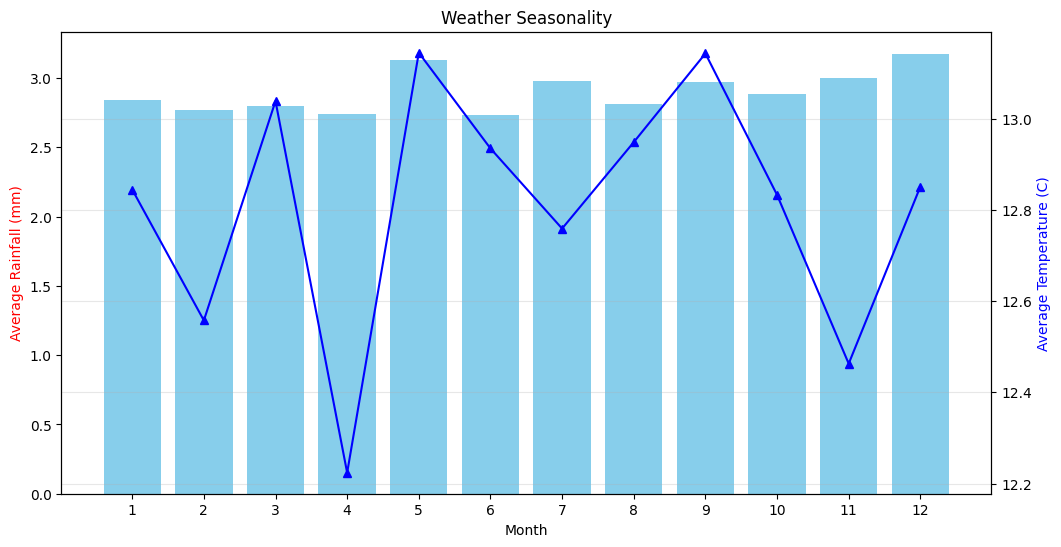

In [12]:
#Seasonality monthly
monthly_data = df.groupby('month').agg(
    rain_mm=('rain_mm', 'mean'),
    temperature=('temperature', 'mean')
).reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(monthly_data['month'], monthly_data['rain_mm'], label='Rainfall (mm)', color='skyblue')
ax.set_xlabel('Month')
ax.set_ylabel('Average Rainfall (mm)', color='r')

ax2 = ax.twinx()
ax2.plot(monthly_data['month'], monthly_data['temperature'], label='Temperature (C)', color='b', marker='^')
ax2.set_ylabel('Average Temperature (C)', color='b')

plt.xticks(range(1, 13, 1))
plt.title('Weather Seasonality')
plt.grid(True, alpha=0.3)
plt.show()

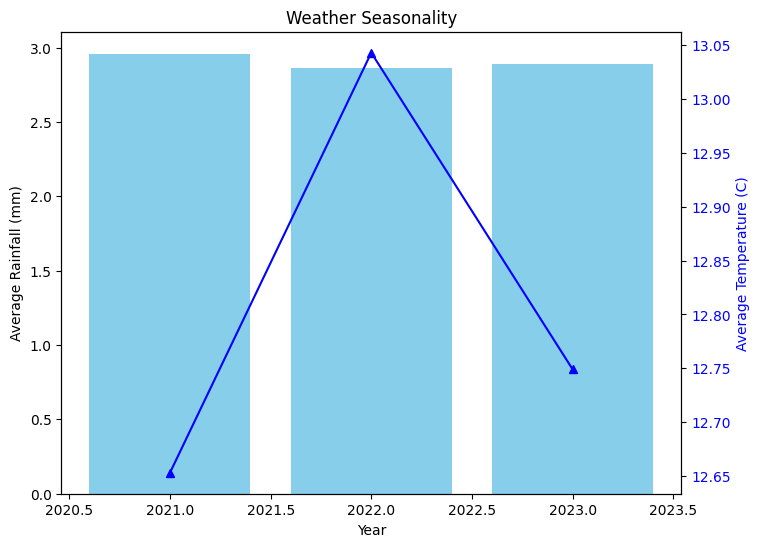

In [ ]:
#Seasonality yearly
yearly_data = df.groupby('year').agg(
    rain_mm=('rain_mm', 'mean'),
    temperature=('temperature', 'mean')
).reset_index()

fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(yearly_data['year'], yearly_data['rain_mm'], label='Rainfall (mm)', color='skyblue')
ax.set_xlabel('Year')
ax.set_ylabel('Average Rainfall (mm)')

ax2 = ax.twinx()
ax2.plot(yearly_data['year'], yearly_data['temperature'], label='Temperature (C)', color='b', marker='^')
ax2.set_ylabel('Average Temperature (C)', color='b')

plt.tick_params(axis='y', labelcolor='b')
plt.title('Weather Seasonality')
plt.xticks(rotation=90)
plt.show()